In [4]:
#Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-05-17 19:52:14.573746: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-17 19:52:14.683163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/yash/.local/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/yash/.local/lib/python3.10/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime versio

In [5]:
#Step 2: Load Dataset
# Load dataset
df = pd.read_csv("8_boston_housing.csv")

# Remove quotes from column names (important for your dataset)
df.columns = df.columns.str.replace('"', '')

# Display first 5 rows
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
#Step 3: Split Features and Target
X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

print(X.shape, y.shape)

(506, 13) (506,)


In [7]:
#Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
#Step 5: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)

Epoch 1/100


/home/yash/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-17 19:52:18.043481: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 620.4470 - mae: 22.8649 - val_loss: 536.0092 - val_mae: 21.4389
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 618.7880 - mae: 22.8556 - val_loss: 535.8276 - val_mae: 21.4440
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 616.9219 - mae: 22.8392 - val_loss: 535.6077 - val_mae: 21.4467
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 615.2219 - mae: 22.8275 - val_loss: 535.3934 - val_mae: 21.4494
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 613.5803 - mae: 22.8151 - val_loss: 535.1848 - val_mae: 21.4529
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 611.8571 - mae: 22.8016 - val_loss: 534.9914 - val_mae: 21.4562
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 610.2502 - mae: 22.7899 - val_loss: 534.8079 - val_mae: 21.4600
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 608.5226 - mae: 22.7756 - val_loss: 534.6240 - val_mae: 21.4627
Epoch 9/100
12/12 ━━━━━━━━

In [10]:
#Step 6: Build Deep Neural Network
model = Sequential()

# Single neuron → behaves like linear regression
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/home/yash/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Step 7: Train Model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 626.0908 - mae: 22.9439 - val_loss: 563.5016 - val_mae: 22.1610
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 623.4668 - mae: 22.9181 - val_loss: 561.7598 - val_mae: 22.1450
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 621.0517 - mae: 22.8993 - val_loss: 560.0789 - val_mae: 22.1285
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 618.7846 - mae: 22.8773 - val_loss: 558.4188 - val_mae: 22.1122
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 616.4136 - mae: 22.8548 - val_loss: 556.8052 - val_mae: 22.0956
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 614.0366 - mae: 22.8312 - val_loss: 555.1870 - val_mae: 22.0793
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 611.6942 - mae: 22.8096 - val_loss: 553.5454 - val_mae: 22.0629
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 609.3305 - mae: 22.7884 - val_loss: 551.9328 - val_mae: 22.0469
Epoch 9/100
21/2

In [12]:
#Step 8: Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 449.9144 - mae: 20.3174
Test Loss (MSE): 449.9143981933594
Test MAE: 20.317363739013672


In [13]:
#Step 9: Predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i][0]:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Actual: 23.60 | Predicted: 4.74
Actual: 32.40 | Predicted: 9.09
Actual: 13.60 | Predicted: -2.59
Actual: 22.80 | Predicted: 5.49
Actual: 16.10 | Predicted: -3.11


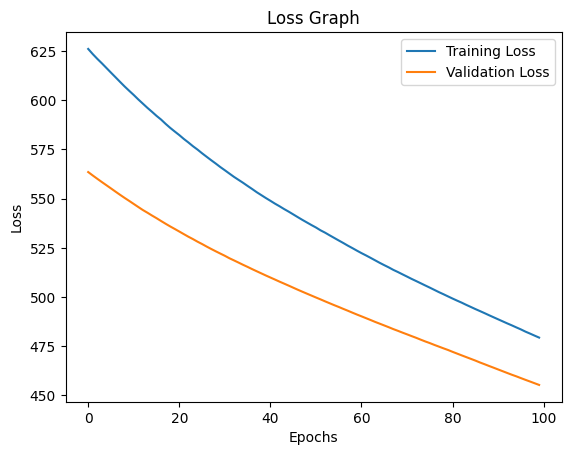

In [14]:
#Step 10: Plot Training Graphs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [15]:
def predict_house_price(features):
    import numpy as np

    # Convert list to numpy array
    features = np.array(features).reshape(1, -1)

    # Scale input same way as training data
    features_scaled = scaler.transform(features)

    # Predict
    predicted_price = model.predict(features_scaled, verbose=0)[0][0]

    return {
        "predicted_price": predicted_price,
        "formatted_price": f"${predicted_price:.2f}k"
    }

In [16]:
feature_info = {
    "CRIM": "Crime rate per capita (0.0 to 90.0) Example: 0.1",
    "ZN": "Residential land zoned (%) (0 to 100) Example: 18",
    "INDUS": "Industrial area proportion (0 to 30) Example: 2.31",
    "CHAS": "Near Charles River? (0 = No, 1 = Yes)",
    "NOX": "Nitric oxide concentration (0.3 to 0.9) Example: 0.538",
    "RM": "Average rooms per dwelling (3 to 9) Example: 6.5",
    "AGE": "Old houses percentage (0 to 100) Example: 65",
    "DIS": "Distance to employment centers (1 to 12) Example: 4.09",
    "RAD": "Highway accessibility index (1 to 24) Example: 5",
    "TAX": "Property tax rate (180 to 720) Example: 296",
    "PTRATIO": "Student-teacher ratio (12 to 22) Example: 15.3",
    "B": "Demographic feature (0 to 400) Example: 396.9",
    "LSTAT": "Lower status population % (1 to 40) Example: 4.98"
}

features = []

print("="*80)
print("INTERACTIVE HOUSE PRICE PREDICTION")
print("Press Enter to use average dataset value")
print("="*80)

for feature, description in feature_info.items():
    while True:
        try:
            value = input(f"\n{feature} ({description}): ")

            if value.strip() == "":
                features.append(X[feature].mean())
                break

            features.append(float(value))
            break

        except ValueError:
            print("Invalid input. Enter a numeric value.")
# Prediction part
print("\n" + "-"*80)

result = predict_house_price(features)

print("\n📊 PREDICTION RESULT:")
print(f"Predicted Price: {result['formatted_price']}")
print(f"Raw Score: {result['predicted_price']:.4f} (in $1000s)")
print("-"*80)

INTERACTIVE HOUSE PRICE PREDICTION
Press Enter to use average dataset value



CRIM (Crime rate per capita (0.0 to 90.0) Example: 0.1):  0.1

ZN (Residential land zoned (%) (0 to 100) Example: 18):  18

INDUS (Industrial area proportion (0 to 30) Example: 2.31):  2.31

CHAS (Near Charles River? (0 = No, 1 = Yes)):  1

NOX (Nitric oxide concentration (0.3 to 0.9) Example: 0.538):  0.538

RM (Average rooms per dwelling (3 to 9) Example: 6.5):  6.5

AGE (Old houses percentage (0 to 100) Example: 65):  65

DIS (Distance to employment centers (1 to 12) Example: 4.09):  4.09

RAD (Highway accessibility index (1 to 24) Example: 5):  22

TAX (Property tax rate (180 to 720) Example: 296):  296

PTRATIO (Student-teacher ratio (12 to 22) Example: 15.3):  15.3

B (Demographic feature (0 to 400) Example: 396.9):  225

LSTAT (Lower status population % (1 to 40) Example: 4.98):  4.98



--------------------------------------------------------------------------------

📊 PREDICTION RESULT:
Predicted Price: $5.14k
Raw Score: 5.1425 (in $1000s)
--------------------------------------------------------------------------------


/home/yash/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
